# Brake Pad Multiobjective Optimization: Pareto Front

This notebook combines the braking-torque and maximum-equivalent-stress surrogate models to identify nondominated brake-pad designs. The Pareto search minimizes **MaxEquivStress** while maximizing **BrakingTorque** over the observed design bounds.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, NonlinearConstraint
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

# Load the same three material datasets used by BrakePadOptm and BrakePadOptm2.
def load_dataset(filename, percentage):
    frame = pd.read_csv(filename, comment='#')
    frame = frame.drop(columns=['P10', 'P11', 'P14', 'P15'])
    frame = frame.rename(columns={
        'Name': 'percentage',
        'P1': 'InnerDiameter',
        'P7': 'ActuationForce',
        'P9': 'SweepAngle',
        'P5': 'MaxEquivStress',
        'P6': 'MaxEquivPlastStrain',
        'P16': 'BrakingTorque',
    })
    frame['percentage'] = float(percentage)
    frame['SweepAngle'] = 180.0 - 2.0 * frame['SweepAngle']
    return frame


data = pd.concat([
    load_dataset('FivePercentCocopeat.csv', 5),
    load_dataset('TenPercentCocopeat.csv', 10),
    load_dataset('FifteenPercentCocopeat.csv', 15),
], ignore_index=True)

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
X = data[features]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

#print(f'Loaded {len(data)} design points with {len(features)} shared input features.')

In [2]:
FEATURES = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
TARGET = ['BrakingTorque', 'MaxEquivStress']

def flag_outliers(df, target=TARGET, iqr_multiplier=2.0):
    q1, q3 = df[target].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - iqr_multiplier * iqr, q3 + iqr_multiplier * iqr
    flagged = df[(df[target] < lower) | (df[target] > upper)]
    return flagged, (lower, upper)

flagged=pd.DataFrame()
for target_response in TARGET:
    flagged_response, bounds = flag_outliers(data, target=target_response)
    flagged = pd.concat([flagged, flagged_response], ignore_index=True)
    print(f"IQR bounds for {target_response}: [{bounds[0]:.2f}, {bounds[1]:.2f}] -- flagged {len(flagged_response)} row(s)")

if len(flagged):
    print(f"\nFlagged {len(flagged)} row(s) -- go verify these FEA runs before trusting any model:")
    display(flagged[FEATURES + TARGET + ['MaxEquivPlastStrain']])
else:
    print("No rows flagged.")


USE_CLEANED_DATA = True
data_model = data.drop(index=flagged.index) if (USE_CLEANED_DATA and len(flagged)) else data
print(f"\nUsing {'cleaned' if (USE_CLEANED_DATA and len(flagged)) else 'full'} dataset for modeling: {len(data_model)} rows")

IQR bounds for BrakingTorque: [261.29, 1570.93] -- flagged 0 row(s)
IQR bounds for MaxEquivStress: [-6.23, 23.90] -- flagged 0 row(s)
No rows flagged.

Using full dataset for modeling: 45 rows


In [3]:
# Use anisotropic Matern kernels with WhiteKernel noise for all three responses.
X_model = data_model[features]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_model)


def fit_surrogate(target):
    kernel = C(1.0, (1e-5, 1e5)) * Matern(
        length_scale=np.ones(len(features)),
        length_scale_bounds=(1e-2, 1e3),
        nu=2.5,
    ) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))
    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=15,
        alpha=1e-3,
        normalize_y=True,
        random_state=42,
    )
    model.fit(X_scaled, target)
    return model


# Log-transform stress because its measured values are positive and right-skewed.
stress_model = fit_surrogate(np.log1p(data_model['MaxEquivStress']))
torque_model = fit_surrogate(data_model['BrakingTorque'])
plastic_strain_model = fit_surrogate(data_model['MaxEquivPlastStrain'])

predicted_stress = np.expm1(stress_model.predict(X_scaled))
predicted_torque = torque_model.predict(X_scaled)
predicted_plastic_strain = plastic_strain_model.predict(X_scaled)
print('Stress, torque, and plastic-strain surrogate models fitted successfully.')
print(f'Stress training R2: {1 - np.sum((data_model["MaxEquivStress"] - predicted_stress) ** 2) / np.sum((data_model["MaxEquivStress"] - data_model["MaxEquivStress"].mean()) ** 2):.4f}')
print(f'Torque training R2: {1 - np.sum((data_model["BrakingTorque"] - predicted_torque) ** 2) / np.sum((data_model["BrakingTorque"] - data_model["BrakingTorque"].mean()) ** 2):.4f}')
print(f'Plastic-strain training R2: {1 - np.sum((data_model["MaxEquivPlastStrain"] - predicted_plastic_strain) ** 2) / np.sum((data_model["MaxEquivPlastStrain"] - data_model["MaxEquivPlastStrain"].mean()) ** 2):.4f}')

/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Stress, torque, and plastic-strain surrogate models fitted successfully.
Stress training R2: 0.9932
Torque training R2: 0.9999
Plastic-strain training R2: 0.9962


In [4]:
# Minimize normalized stress and maximize normalized torque for many trade-off weights.
bounds = [(X[feature].min(), X[feature].max()) for feature in features]
stress_min = float(data_model['MaxEquivStress'].min())
stress_max = float(data_model['MaxEquivStress'].max())
torque_min = float(data_model['BrakingTorque'].min())
torque_max = float(data_model['BrakingTorque'].max())


def predict_objectives(values):
    candidate = pd.DataFrame([values], columns=features)
    candidate_scaled = scaler_X.transform(candidate)
    stress = float(np.expm1(stress_model.predict(candidate_scaled)[0]))
    torque = float(torque_model.predict(candidate_scaled)[0])
    plastic_strain = float(plastic_strain_model.predict(candidate_scaled)[0])
    return stress, torque, plastic_strain


def plastic_strain_constraint(values):
    """Feasible candidates satisfy predicted MaxEquivPlastStrain <= 0."""
    return predict_objectives(values)[2]


def scalarized_objective(values, stress_weight):
    stress, torque, _ = predict_objectives(values)
    normalized_stress = (stress - stress_min) / (stress_max - stress_min)
    normalized_torque = (torque_max - torque) / (torque_max - torque_min)
    return stress_weight * normalized_stress + (1.0 - stress_weight) * normalized_torque


tradeoff_weights = np.linspace(0.0, 1.0, 31)
plastic_constraint = NonlinearConstraint(plastic_strain_constraint, -np.inf, 0.0)
solutions = []
for stress_weight in tradeoff_weights:
    result = differential_evolution(
        lambda values: scalarized_objective(values, stress_weight),
        bounds=bounds,
        constraints=(plastic_constraint,),
        seed=42,
        polish=True,
        maxiter=150,
        popsize=12,
    )
    stress, torque, plastic_strain = predict_objectives(result.x)
    solutions.append({
        'Stress Weight': stress_weight,
        **dict(zip(features, result.x)),
        'Predicted MaxEquivStress': stress,
        'Predicted BrakingTorque': torque,
        'Predicted MaxEquivPlastStrain': plastic_strain,
        'Optimization Successful': result.success,
    })

solutions = pd.DataFrame(solutions)

# Keep a point when no other feasible point is at least as good in both objectives.
def pareto_mask(frame):
    objective_values = frame[['Predicted MaxEquivStress', 'Predicted BrakingTorque']].to_numpy()
    is_dominated = np.zeros(len(frame), dtype=bool)
    for index, point in enumerate(objective_values):
        no_worse = (objective_values[:, 0] <= point[0]) & (objective_values[:, 1] >= point[1])
        strictly_better = (objective_values[:, 0] < point[0]) | (objective_values[:, 1] > point[1])
        is_dominated[index] = np.any(no_worse & strictly_better)
    return ~is_dominated


pareto_front = solutions.loc[pareto_mask(solutions)].sort_values('Predicted MaxEquivStress').reset_index(drop=True)
print(f'Found {len(pareto_front)} feasible nondominated surrogate designs.')
print(f'Maximum predicted plastic strain on Pareto front: {pareto_front["Predicted MaxEquivPlastStrain"].max():.3e}')
display(pareto_front.round(3))

Found 26 feasible nondominated surrogate designs.
Maximum predicted plastic strain on Pareto front: -6.507e-11


,Stress Weight,percentage,InnerDiameter,ActuationForce,SweepAngle,Predicted MaxEquivStress,Predicted BrakingTorque,Predicted MaxEquivPlastStrain,Optimization Successful
0,0.933,5.000,125.500,-10333.334,85.533,3.818,733.110,-0.0,True
1,0.867,5.000,125.500,-11115.946,85.533,3.978,786.221,-0.0,True
2,0.733,5.000,125.500,-11115.987,85.533,3.978,786.224,-0.0,True
3,0.833,10.000,130.043,-11896.874,85.071,8.254,790.163,-0.0,True
4,0.800,10.002,129.926,-12076.735,85.477,8.323,805.238,-0.0,True
5,0.767,10.001,128.963,-12566.610,85.444,8.562,848.694,-0.0,True
6,0.700,9.999,126.299,-16945.925,85.533,11.081,1176.520,-0.0,True
7,0.667,10.001,126.346,-17432.967,85.492,11.387,1208.320,-0.0,True
8,0.633,9.999,126.616,-17898.890,85.509,11.698,1235.642,-0.0,True
9,0.567,9.999,126.804,-18201.761,85.530,11.902,1253.055,-0.0,True


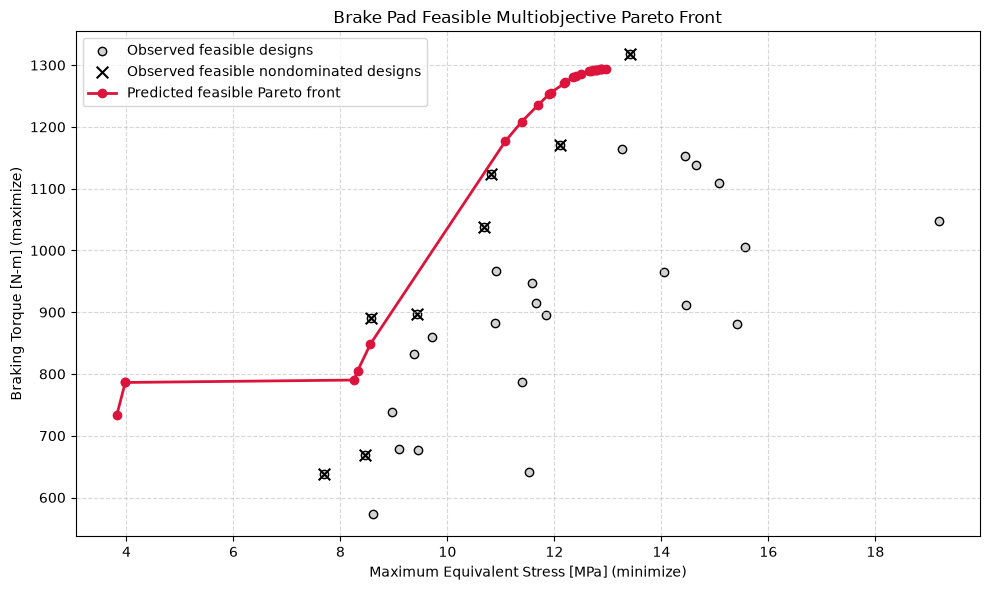

Balanced feasible compromise design


,Stress Weight,percentage,InnerDiameter,ActuationForce,SweepAngle,Predicted MaxEquivStress,Predicted BrakingTorque,Predicted MaxEquivPlastStrain,Optimization Successful
15,0.5,10.0,127.182,-18584.63,85.524,12.189,1272.381,-0.0,True


In [5]:
# Compare the feasible surrogate Pareto front with feasible observed designs.
feasible_data = data_model[data_model['MaxEquivPlastStrain'] <= 0].copy()
observed_front = feasible_data.loc[
    pareto_mask(pd.DataFrame({
        'Predicted MaxEquivStress': feasible_data['MaxEquivStress'],
        'Predicted BrakingTorque': feasible_data['BrakingTorque'],
    }))
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    feasible_data['MaxEquivStress'],
    feasible_data['BrakingTorque'],
    color='lightgray',
    edgecolor='black',
    label='Observed feasible designs',
)
plt.scatter(
    observed_front['MaxEquivStress'],
    observed_front['BrakingTorque'],
    color='black',
    marker='x',
    s=70,
    label='Observed feasible nondominated designs',
)
plt.plot(
    pareto_front['Predicted MaxEquivStress'],
    pareto_front['Predicted BrakingTorque'],
    color='crimson',
    marker='o',
    linewidth=2,
    label='Predicted feasible Pareto front',
)
plt.xlabel('Maximum Equivalent Stress [MPa] (minimize)')
plt.ylabel('Braking Torque [N-m] (maximize)')
plt.title('Brake Pad Feasible Multiobjective Pareto Front')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Select a balanced feasible compromise using equal normalized weights.
balanced_design = solutions.iloc[(solutions['Stress Weight'] - 0.5).abs().argmin()]
print('Balanced feasible compromise design')
display(pd.DataFrame([balanced_design]).round(3))